# Phase Graph of GLV and GLV term RD model
Longxiao, LMU
python version: 3.10.19

This is a python notebook used to draw the phase graph of ODEs used in general ecology model.

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar
from scipy.integrate import cumulative_trapezoid

2D-phase graph

In [14]:
class PhasePlotter2D:
    def __init__(self, model, params=None):
        self.model = model
        self.params = params or ()
        #self.solution = None
    
    # draw trajectory
    def plot_solve(self, ax, init_conds, t_end=20, dt=0.01, color='black', lw=2):

        init_conds = np.atleast_2d(init_conds)
        t_eval = np.arange(0, t_end, dt)

        for init in init_conds:
            sol = solve_ivp(
                lambda t, y: self.model(t, y, *self.params),
                (0, t_end),
                init,
                t_eval=t_eval
            )
            ax.plot(sol.y[0], sol.y[1], color=color, lw=lw)
            ax.plot(sol.y[0][0], sol.y[1][0], 'ro', markersize=4) 

        return ax

    #draw phase graph,the vector field
    def plot_phase_diagram(self, x_range, y_range, density=1.5, ax=None):

        ax = ax or plt.gca()
        
        # grids
        x = np.linspace(*x_range, int(20*density))
        y = np.linspace(*y_range, int(20*density))
        X, Y = np.meshgrid(x, y)
        
        # calculate and draw vector field
        # vector defined by the local derivative
        DX, DY = self.model(0, np.array([X, Y]), *self.params)
        norm = np.hypot(DX, DY) + 1e-8
        
        ax.quiver(X, Y, DX/norm, DY/norm, 
                 color='gray', 
                 scale=40/density,
                 width=0.005,
                 pivot='mid')
            
        ax.set(xlim=x_range, ylim=y_range,
              xlabel='x', ylabel='y')
        return ax

    #draw null-clines for each equation/item 
    def plot_nullclines(self, x_range, y_range, resolution=500, ax=None):
        ax = ax or plt.gca()
        x = np.linspace(*x_range, resolution)
        y = np.linspace(*y_range, resolution)
        X, Y = np.meshgrid(x, y)
        
        # store the result
        DX = np.zeros_like(X)
        DY = np.zeros_like(Y)
        
        # calculate dx/dt and dy/dt for each grid
        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                dxdt, dydt = self.model(0, [X[i, j], Y[i, j]], *self.params)
                DX[i, j], DY[i, j] = dxdt, dydt

        # draw null-clines
        # where either dx/dt or dy/dt is 0
        ax.contour(X, Y, DX, levels=[0], colors='darkred', linewidths=1.5)
        ax.contour(X, Y, DY, levels=[0], colors='navy', linewidths=1.5)
        
        legend_elements = [
            Line2D([0], [0], color='darkred', lw=1.5, label='dx/dt=0'),
            Line2D([0], [0], color='navy', lw=1.5, label='dy/dt=0')
        ]
        ax.legend(handles=legend_elements)
        return ax

Example: Lotka-Volterra model
$$
\frac{\mathrm{d} x}{\mathrm{d}t} = x ( r_1 - a_1 y )\\
\frac{\mathrm{d} y}{\mathrm{d}t} = y ( r_2 - a_2 x )
$$

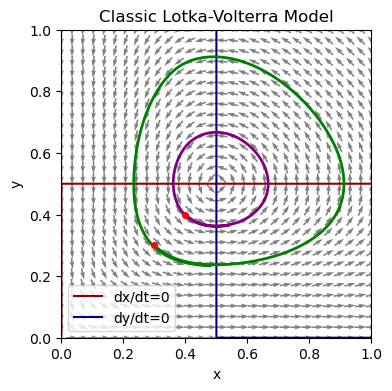

In [20]:
# L-V
# L-V function   
def lv_2species(t, vars, r1, r2, a1, a2):
    x, y = vars
    return np.array([
        x * ( r1 - a1 * y ),
        y * ( r2 - a2 * x )
    ])
    
# parameters r1, r2, a1, a2
params = (0.5,-0.5,1,-1) 
    
plotter = PhasePlotter2D(lv_2species, params=params)
    
#draw
fig, ax = plt.subplots(figsize=(4, 4))
    
plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

ax = plotter.plot_solve(ax, [[0.3,0.3]], t_end=15, dt=0.01, color='green')
ax = plotter.plot_solve(ax, [[0.4,0.4]], t_end=15, dt=0.01, color='purple')
    
#ax.legend()
plt.title("Classic Lotka-Volterra Model")
plt.show()


Another example: Generalized Lotka-Volterra model
$$
\frac{\mathrm{d} x}{\mathrm{d}t} = x ( r_1 - x - a_1 y )\\
\frac{\mathrm{d} y}{\mathrm{d}t} = y ( r_2 - a_2 x - y )
$$

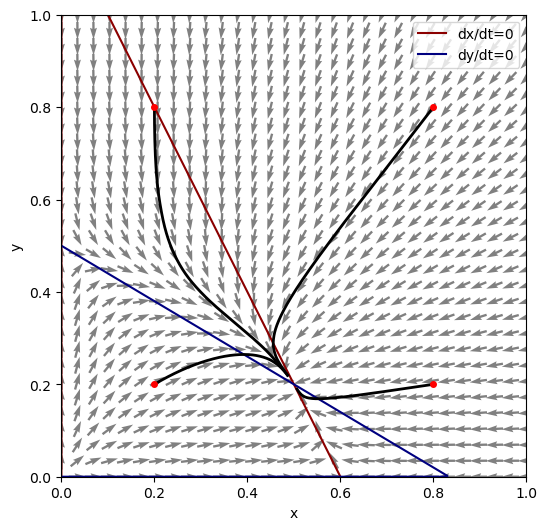

In [22]:

def glv_2species(t, vars, r1, r2, a1, a2):
    x, y = vars
    return np.array([
        r1*x - x**2 - a1 * x * y,
        r2*y - y**2 - a2 * y * x
    ])

params = (0.6,0.5,0.5,0.6) 

plotter = PhasePlotter2D(glv_2species, params=params)

fig, ax = plt.subplots(figsize=(6, 6))

plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
plotter.plot_nullclines((0, 1), (0, 1), ax=ax)

plotter.plot_solve(ax, [[0.2,0.2]], t_end=15, dt=0.01)
ax = plotter.plot_solve(ax, [[0.2,0.8]], t_end=15, dt=0.01)
ax = plotter.plot_solve(ax, [[0.8,0.8]], t_end=15, dt=0.01)
ax = plotter.plot_solve(ax, [[0.8,0.2]], t_end=15, dt=0.01)

plt.show()


Here is a stable equilibrium in the center, where both species could coexist. We explore a lit bit more about the parameter space:

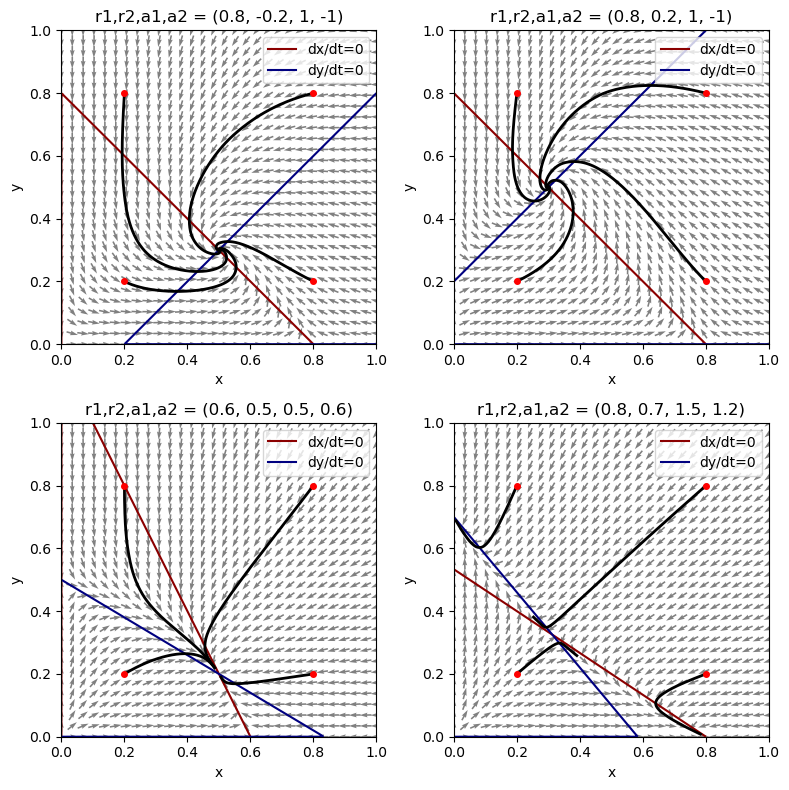

In [23]:
# four different parameter combinations
params_com  = [(0.8,   -0.2,   1,  -1), 
                (0.8,   0.2,    1,  -1), 
                (0.6,   0.5,    0.5,0.6), 
                (0.8,   0.7,    1.5,1.2)]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()

for i in range(0,4):
    ax = axes[i]
    
    plotter = PhasePlotter2D(glv_2species, params=params_com[i])
    
    plotter.plot_phase_diagram((0, 1), (0, 1), ax=ax)
    plotter.plot_nullclines((0, 1), (0, 1), ax=ax)
    
    # 绘制轨迹
    plotter.plot_solve(ax, [0.2,0.2], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.2,0.8], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.8,0.2], t_end=15, dt=0.01)

    plotter.plot_solve(ax, [0.8,0.8], t_end=15, dt=0.01)
    
    ax.set_title(f"r1,r2,a1,a2 = {params_com[i]}")

plt.tight_layout()
plt.show()

With some parameters species could coexist, but with others, for example, the forth, there is always one species died out, which is called competition exclusive.

---

Now we want to discuss spatial dynamics models, where individuals dispersal in a homogeneous continuous space. For one species, the model normally like
$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + f(u)
$$
where the first term models random dispersal, while the second is reaction term.

We consider the following two different reaction term
$$
f(u) = u(1-u)\\
f(u) = u(1-u)^2
$$
System with the first reaction is called **Fisher-KPP** model, and the later one **Allen-Cahn**model.

We first discuss the dynamics of only the reaction term, which is a dynamics on 1-dimension space.

Here we draw the following graph:
- the reaction function it self
- the "potential" in the space
the potential $W(u)$ is defined as
$$
\frac{\mathrm{d}W}{\mathrm{d}u} = f(u)
$$ 

In [36]:
class OneDimensionalDynamicalSystem:
    def __init__(self, f, u_range=(-2, 2), params=None, num_points=1000):
        # f: reaction function in the form of f(u, **params)
        self.f = f
        self.params = params if params is not None else {}
        self.u_min, self.u_max = u_range
        self.num_points = num_points

        self.u = np.linspace(self.u_min, self.u_max, self.num_points)
        self.f_values = self.f(self.u, **self.params)

        self.fixed_points = self.find_fixed_points()
        self.stability = self.analyze_stability()
        self.W_values = self.compute_potential()

    def find_fixed_points(self, tol=1e-6):
        fixed_points = []
        for i in range(len(self.u) - 1):
            u1, u2 = self.u[i], self.u[i + 1]
            f1, f2 = self.f_values[i], self.f_values[i + 1]

            # check zero point:
            # 1. f = 0
            if f1 == 0:
                fixed_points.append(u1)
            # 2. curve cross the x axis in between
            elif f1 * f2 < 0:
                try:
                    sol = root_scalar(
                        lambda x: self.f(x, **self.params),
                        bracket=[u1, u2],
                        method='brentq'
                    )
                    fixed_points.append(sol.root)
                except ValueError:
                    pass

        # remove repetitive
        fixed_points = np.array(fixed_points)
        fixed_points = np.unique(np.round(fixed_points, 6))

        return fixed_points

    def numerical_derivative(self, x, h=1e-5):
        return (
            self.f(x + h, **self.params)
            - self.f(x - h, **self.params)
        ) / (2 * h)

    def analyze_stability(self):
        stability = {}

        # check the stability of each fixed point
        # the point is stable only if the derivative here is negative
        for fp in self.fixed_points:
            derivative = self.numerical_derivative(fp)
            if derivative < 0:
                stability[fp] = 'stable'
            elif derivative > 0:
                stability[fp] = 'unstable'
            else:
                stability[fp] = 'neutral'

        return stability
    
    def compute_potential(self):
        # calculate the potential, define W(0) = 0
        minus_f = -self.f_values
        W = cumulative_trapezoid(minus_f, self.u, initial=0)
        W0 = np.interp(0, self.u, W)
        W -= W0
        return W
    
    #draw

    def plot_phase_line(self, ax, y_position=0, x_range=None):
        # draw the back ground color and flux in x axis.
        if x_range is None:
            x_min, x_max = self.u_min, self.u_max
        else:
            x_min, x_max = x_range

        visible_fixed_points = [fp for fp in self.fixed_points if x_min < fp < x_max]
        points = [x_min] + list(visible_fixed_points) + [x_max]

        region_colors = {
            1: 'lightblue',
            -1: 'moccasin'
        }

        for i in range(len(points) - 1):
            left = points[i]
            right = points[i + 1]
            mid = 0.5 * (left + right)

            # flux direction is the same in region, which is the direction in the middle
            direction = np.sign(self.f(mid, **self.params))

            # draw background color
            if direction != 0:
                ax.axvspan(
                    left,
                    right,
                    alpha=0.15,
                    color=region_colors.get(direction, 'lightgray')
                )

            # draw flux arrow
            if direction > 0:
                ax.annotate(
                    '',
                    xy=(right, y_position),
                    xytext=(left, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='blue',
                        linewidth=2
                    )
                )
            elif direction < 0:
                ax.annotate(
                    '',
                    xy=(left, y_position),
                    xytext=(right, y_position),
                    arrowprops=dict(
                        arrowstyle='->',
                        color='orange',
                        linewidth=2
                    )
                )

    def plot_function(self, ax=None, figsize=(5, 3), xlim=None, ylim=None):
        # draw the function curve
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.f_values, linewidth=2, label='f(u)')
        ax.axhline(0, color='black', linewidth=1)

        for fp in self.fixed_points:
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, 0, color=color, s=80, zorder=5)
            ax.text(
                fp,
                0.05 * (np.max(self.f_values) - np.min(self.f_values)),
                f'{fp:.2f}{stability}',
                ha='center',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        phase_x_range = xlim if xlim is not None else (self.u_min, self.u_max)
        self.plot_phase_line(ax, y_position=y_phase, x_range=phase_x_range)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        #ax.set_title('f(u)')
        ax.set_xlabel('u')
        ax.set_ylabel('f(u)')
        #ax.grid(True)
        ax.legend()

        if created_fig:
            plt.show()

    def plot_potential(self, ax=None, figsize=(5, 3), xlim=None, ylim=None):
        # draw potential curve
        created_fig = False

        if ax is None:
            fig, ax = plt.subplots(figsize=figsize)
            created_fig = True

        ax.plot(self.u, self.W_values, linewidth=2, label='W(u)')

        for fp in self.fixed_points:
            W_fp = np.interp(fp, self.u, self.W_values)
            stability = self.stability[fp]

            if stability == 'stable':
                color = 'green'
            elif stability == 'unstable':
                color = 'red'
            else:
                color = 'gray'

            ax.scatter(fp, W_fp, color=color, s=80, zorder=5)
            ax.text(
                fp,
                W_fp,
                f'{fp:.2f}{stability}',
                ha='center',
                va='bottom',
                color=color
            )

        y_phase = np.min(self.W_values) - 0.1 * (
            np.max(self.W_values) - np.min(self.W_values)
        )

        phase_x_range = xlim if xlim is not None else (self.u_min, self.u_max)
        self.plot_phase_line(ax, y_position=y_phase, x_range=phase_x_range)

        if xlim is not None:
            ax.set_xlim(xlim)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_xlabel('u')
        ax.set_ylabel('W(u)')
        ax.legend()

        if created_fig:
            plt.show()

For Fisher-KPP model the reaction has one stable equilibrium.

equilibrium:
u = 0.000000, unstable
u = 1.000000, stable


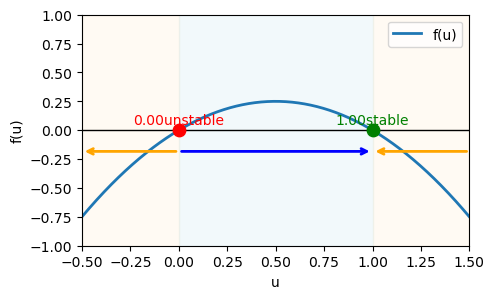

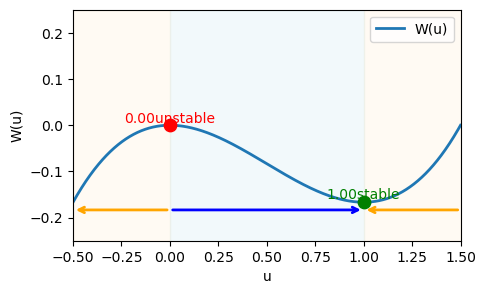

In [39]:
def f(u):
    return u*(1-u)


system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-0.5,1.5)
)

print('equilibrium:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-0.5,1.5),ylim=(-1,1))
system.plot_potential(xlim=(-0.5,1.5),ylim=(-0.25,0.25))

For the Allen-Cahn reaction, there are two stable equilibrium.

equilibrium:
u = 0.000000, stable
u = 0.500000, unstable
u = 1.000000, stable


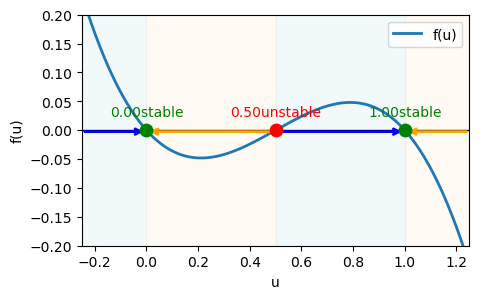

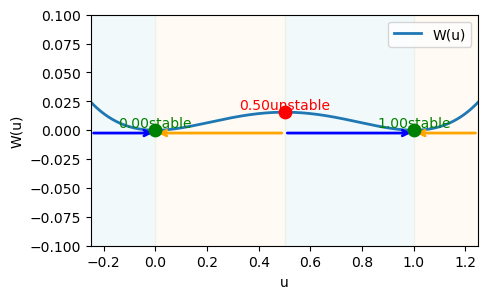

In [ ]:
def f(u, a=0.5):
    return u*(1-u)*(u-a)

system = OneDimensionalDynamicalSystem(
    f=f,
    u_range=(-0.25,1.25),
    params={'a': 0.5}
)

print('equilibrium:')
for fp in system.fixed_points:
    print(f'u = {fp:.6f}, {system.stability[fp]}')

system.plot_function(xlim=(-0.25,1.25),ylim=(-0.2,0.2))
system.plot_potential(xlim=(-0.25,1.25),ylim=(-0.1,0.1))

Now, we consider a traveling wave solution for the full model:
$$
\frac{\partial u}{\partial t} = \frac{\partial^2 u}{\partial x^2} + f(u)
$$

let $z = x - ct$, then $u(x,t) = u(z)$, and
$$
\frac{\partial u}{\partial t} = -c\frac{\mathrm{d} u}{\mathrm{d} z}\\
\frac{\partial^2 u}{\partial x^2} = \frac{\mathrm{d}^2 u}{\mathrm{d} z^2}
$$
Then the partial differential equation will be transformed as an second ordered ODE
$$
\frac{\mathrm{d}^2 u}{\mathrm{d} z^2} + c\frac{\mathrm{d} u}{\mathrm{d} z} + f(u) = 0
$$

We could then consider such a system in a phase plane, by dividing it as two ODEs
$$
\dot{u} = p\\
\dot{p} = - c p - f(u)
$$

We draw the phase plane for both system, and also show the heteroclinic orbit. Integral along the heteroclinic orbit, we could get the structure of $u(z)$.

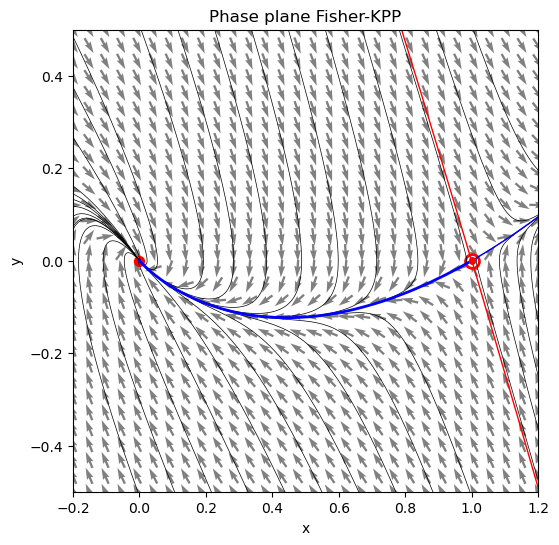

In [43]:
def Fisher_KPP(t, vars, c):
    u, p = vars
    return np.array([
        p,
        -c*p - u*(1-u)
    ])

params = (2,) 

plotter = PhasePlotter2D(Fisher_KPP, params=params)

fig, ax = plt.subplots(figsize=(6, 6))
for i in np.linspace(0, 1, 10):
    ax = plotter.plot_solve(ax, [i,0.51], t_end=10, dt=0.01, lw = 0.5)
    ax = plotter.plot_solve(ax, [i,-0.51], t_end=10, dt=0.01, lw = 0.5)
    ax = plotter.plot_solve(ax, [1.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
    ax = plotter.plot_solve(ax, [-0.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)

ax = plotter.plot_solve(ax, [[1,-0.001]], t_end=100, dt=0.01, color='blue',lw=2)
ax = plotter.plot_solve(ax, [[1,0.001]], t_end=100, dt=0.01, color='blue',lw = 1)
ax = plotter.plot_solve(ax, [[1.208,-0.51]], t_end=10, dt=0.01, color='red',lw = 1)
ax = plotter.plot_solve(ax, [[0.785,0.51]], t_end=10, dt=0.01, color='red',lw = 1)

plotter.plot_phase_diagram((-0.2, 1.2), (-0.5, 0.5), ax=ax,density=1.5)
#plotter.plot_nullclines((-0.2, 1.2), (-0.2, 1.2), ax=ax)
ax.scatter(0, 0, color='red', s=50)
ax.scatter(1, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)

plt.title("Phase plane Fisher-KPP")
plt.show()

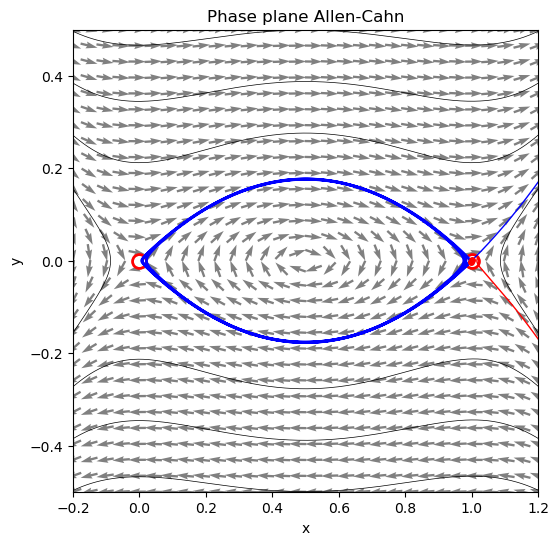

In [42]:
def Fisher_KPP(t, vars, c):
    u, p = vars
    return np.array([
        p,
        -c*p - u*(1-u)*(u-0.5)
        #-c*p+u**2-u**3
    ])

params = (0,) 

plotter = PhasePlotter2D(Fisher_KPP, params=params)

fig, ax = plt.subplots(figsize=(6, 6))
for i in np.linspace(0, 1, 10):
    #ax = plotter.plot_solve(ax, [i,0.51], t_end=10, dt=0.01, lw = 0.5)
    #ax = plotter.plot_solve(ax, [i,-0.51], t_end=10, dt=0.01, lw = 0.5)
    ax = plotter.plot_solve(ax, [1.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)
    ax = plotter.plot_solve(ax, [-0.21,i-0.5], t_end=10, dt=0.01, lw = 0.5)

ax = plotter.plot_solve(ax, [[1-0.003,-0.003]], t_end=100, dt=0.01, color='blue',lw=2)
ax = plotter.plot_solve(ax, [[1,0.001]], t_end=10, dt=0.01, color='blue',lw = 1)
ax = plotter.plot_solve(ax, [[1.21,-0.179]], t_end=5, dt=0.01, color='red',lw = 1)
#ax = plotter.plot_solve(ax, [[0.785,0.51]], t_end=10, dt=0.01, color='red',lw = 1)

plotter.plot_phase_diagram((-0.2, 1.2), (-0.5, 0.5), ax=ax)
#plotter.plot_nullclines((-0.2, 1.2), (-0.5, 0.5), ax=ax)

#ax.scatter(0.5, 0, color='red', s=50)
ax.scatter(0, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)
ax.scatter(1, 0, facecolors='white', edgecolors='red', s=100, linewidths=2)

plt.title("Phase plane Allen-Cahn")
plt.show()